In [39]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
%matplotlib inline

### A1. Data Wrangling

In [40]:
# A1.1

# Load the csv data file for data wrangling
student_list_data = pd.read_csv("Student_List_A2.csv")
student_list_data.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,1
1,1003,15,4.210570,26,2,0.112602,4
2,1004,17,10.028829,14,3,2.054218,3
3,1005,17,4.672495,17,3,1.288061,4
4,1006,18,8.191219,0,1,3.084184,1


In [41]:
# A1.2

# Define a function that assigns alphabetical grades to students based on their numerical grades
def apply_letter_grade(x):
    if x == 0:
        return "A"
    elif x == 1:
        return "B"
    elif x == 2:
        return "C"
    elif x == 3:
        return "D"
    else:
        return "F"

# Apply alphabetical grades to students
student_list_data["GradeClass"] = student_list_data["GradeClass"].apply(apply_letter_grade)
student_list_data

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B
...,...,...,...,...,...,...,...
2095,3386,16,1.445434,20,3,1.395631,B
2096,3388,18,10.680555,2,4,3.455509,A
2097,3390,16,6.805500,20,2,1.142333,C
2098,3391,16,12.416653,17,2,1.803297,B


In [42]:
# A1.3

# Identifying missing values in the columns
print("Total missing values in the dataset is:")
student_list_data.isna().sum()

Total missing values in the dataset is:


StudentID           0
Age                 0
StudyTimeWeekly    21
Absences            0
ParentalSupport     0
GPA                 0
GradeClass          0
dtype: int64

In [43]:
# Since there are only missing value in the "StudyTimeWeekly", I only need to calculate the median value for that column to replace

# First, I extract only the values from the StudyTimeWeekly column, remove the missing values from the column and sort the column ascending and store into another DataFrame
sorted_weekly_study_time = student_list_data.dropna().sort_values(by=['StudyTimeWeekly'], ascending = True)['StudyTimeWeekly']
# sorted_weekly_study_time

# After having the values sorted, I calculate the median value using median() funcion in numpy and store it into a variable
weekly_study_time_median = np.median(sorted_weekly_study_time)
# weekly_study_time_median

# Finally, I replace all missing values from the StudyTimeWeekly column with the newly calculated median value of the column
student_list_data['StudyTimeWeekly'] = student_list_data['StudyTimeWeekly'].fillna(weekly_study_time_median)

# Show the count of missing values after the replacement
print("Total missing values after the replacement is:")
student_list_data.isna().sum()

Total missing values after the replacement is:


StudentID          0
Age                0
StudyTimeWeekly    0
Absences           0
ParentalSupport    0
GPA                0
GradeClass         0
dtype: int64

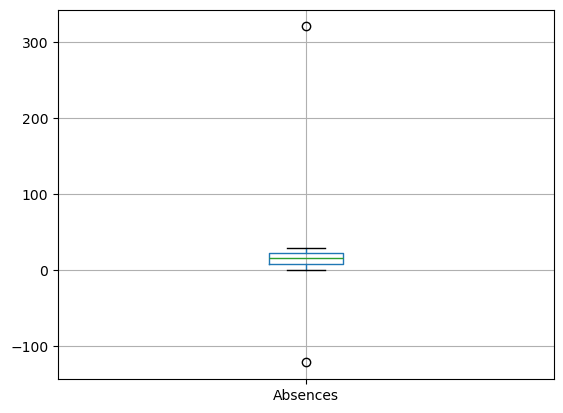

In [44]:
# A1.4

# Detect a data quality problem related to the 'Absences' column

# There is a column name. Therefore, it is not an interpretability issue
# The column is in a datasest. Therefore, it came from only one source. Hence, it is in the same format and is not a data format issue
# By skimming through the column, I see that there are no inconsistent data. Therefore, it is also not an inconsistent and faulty data issue
# By counting missing values in the dataset in the above steps, I can confirm that there is no missing value in this column. Therefore, it is not a missing values issue
# I didn't check if there are outliers in the dataset. Therefore, I am going to check if there is any outliers in the data
# Since there maybe some students with the same absence counts, duplicates are accepted and there is no duplicate issues in the dataset

# The goal of the step if to check if any data is larger than the upper bound for mild outliers
# of is smaller than the lower bound for mild outliers or is lower than 0 since there can not be a negative number of absence count

# First, I visualize the data in the 'Absensces' column using a box plot. The box plot also shows the lower and upper bound for mild outliers, which helps me identify outliers more easily
student_list_data.boxplot(column = 'Absences')
plt.show()

(2098, 7)


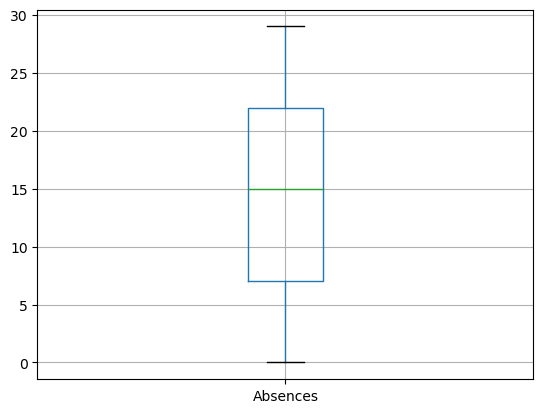

In [45]:
# As shown by the box plot, the lower bound for mild outliers is equal to 0 and the upper bound for mild outliers is around 30
# Therefore, I need to delete the rows which 0 <= student_list_data['Absences'] <= 30

# Filter the rows in the data with the above conditions
filt = ~((student_list_data['Absences'] < 0) | (student_list_data['Absences'] > 30))

# Apply the filter to the dataset
student_list_data = student_list_data[filt]


# Check the dataset after filtering
print(student_list_data.shape)
student_list_data.boxplot(column = 'Absences')
plt.show()

In [46]:
# A1.5

# Define a function to apply the grade based on the student's gpa score
def apply_grade_by_gpa(gpa):
    if gpa >= 3.5:
        return "A"
    elif gpa >= 3.0:
        return "B"
    elif gpa >= 2.5:
        return "C"
    elif gpa >= 2.0:
        return "D"
    else:
        return "F"

# Create a new column in the dataset to store the student's expected grade based on the GPA score
student_list_data['ExpectedGrade'] = student_list_data['GPA'].apply(apply_grade_by_gpa)

# Count the inconsistencies between "GPA" and "GradeClass" within the dataset

# Create a new dataframe that stores students that have actual grade differs from the expected grade
inconsistencies_count = student_list_data[student_list_data['GradeClass'] != student_list_data['ExpectedGrade']]
# Output the number of inconsistencies by printing the size of the dataframe
print(len(inconsistencies_count))

100


C:\msys64\tmp\ipykernel_16052\2145834757.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_list_data['ExpectedGrade'] = student_list_data['GPA'].apply(apply_grade_by_gpa)


In [47]:
# As shown, there are inconsistencies between the student's GPA score and Grade.
# In this case, I choose the column "GPA" to trust as the grade is retrieved from the GPA score.
# Meanwhile, it is more reasonable to make mistakes when inputting Grades than GPA score.

# Correct the grade class based on GPA by applying the apply_grade_by_gpa function
student_list_data['GradeClass'] = student_list_data['GPA'].apply(apply_grade_by_gpa)

# Recheck to ensure there is no more inconsistencies
inconsistencies_count = student_list_data[student_list_data['GradeClass'] != student_list_data['ExpectedGrade']]
print(len(inconsistencies_count))

0


C:\msys64\tmp\ipykernel_16052\77035557.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_list_data['GradeClass'] = student_list_data['GPA'].apply(apply_grade_by_gpa)


In [48]:
# Since the output is "0", we can confirm there is no more inconsistencies between two columns

# Delete the "ExpectedGrade" to return to the original format of the dataset
student_list_data = student_list_data.drop(columns = ['ExpectedGrade'])

student_list_data.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B


### A2. Data Exploration and Visualization

In [49]:
# A2.1

# Count the total number of students
total_students_count = len(student_list_data)
print(total_students_count)

# Count the numbers of students in each grade
grade_counts = student_list_data['GradeClass'].value_counts()
print(grade_counts)

2098
GradeClass
F    1125
D     369
C     339
B     204
A      61
Name: count, dtype: int64


In [50]:
# Calculate the percentage of students in each grade
grade_percentage = (grade_counts / total_students_count) * 100
grade_percentage = grade_percentage.round(2).astype(str) + "%"
print(grade_percentage, "%")

GradeClass
F    53.62%
D    17.59%
C    16.16%
B     9.72%
A     2.91%
Name: count, dtype: object %


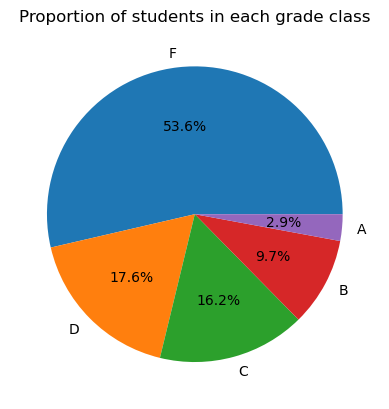

In [51]:
# A2.2

# Define an array of labels for the pie chart
# grade_labels = student_list_data['GradeClass'].unique()
grade_labels = grade_percentage.index

# Plot the pie chart using pyplot
plt.pie(grade_counts, labels = grade_labels, autopct='%1.1f%%')
plt.title("Proportion of students in each grade class")
plt.show()

Base on the pie chart, over 53% of students scored an F, meaning the overall performance is really bad.
C and D grades add up to a third of the dataset, indicating many are performing in the lower-to-mid range.
Only 9.7% scored B and 2.9% scored A means that high level of performance is rare in the students.

#### A2.3

Based on the percentages on the pie chart and the calculated percentages, I noticed that there are minimal differences between them.
This is mostly due to the round number where when I calculated it I rounded to 2-digit precision while the pie chart is showing 1-digit precision.
To prove my statement, I will draw another pie chart that shows the percentage in 2-digit precision

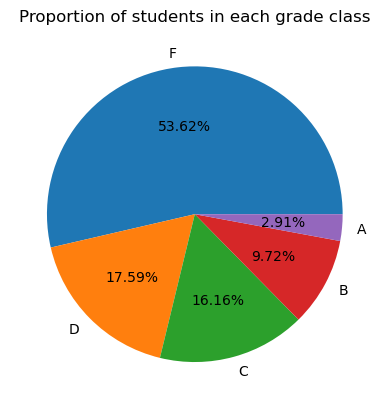

In [52]:
# Plot the pie chart using pyplot, this time representing the percentage using 2-digit precision percentages
plt.pie(grade_counts, labels = grade_labels, autopct='%1.2f%%')
plt.title("Proportion of students in each grade class")
plt.show()

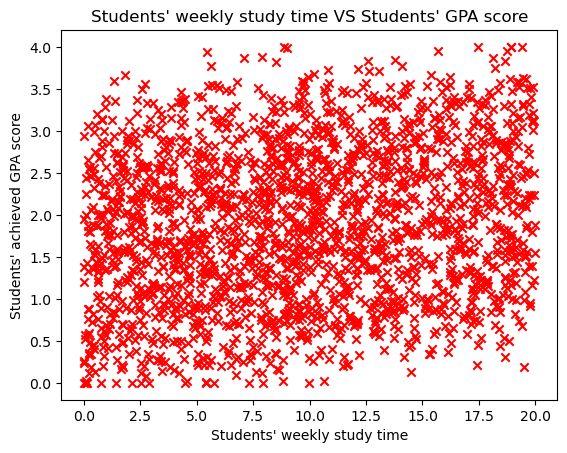

In [53]:
# A2.4

# Since the requirement to to show the relationship between two features, I choose the scatter plot to do so.
students_weekly_study_time = student_list_data['StudyTimeWeekly']
students_gpa_score = student_list_data['GPA']

plt.scatter(students_weekly_study_time, students_gpa_score, marker = 'x', color = 'r')
plt.xlabel("Students' weekly study time")
plt.ylabel("Students' achieved GPA score")
plt.title("Students' weekly study time VS Students' GPA score")
plt.show()

In [54]:
corr = student_list_data['StudyTimeWeekly'].corr(student_list_data['GPA'])
print("Correlation between StudyTime and GPA:", corr)

Correlation between StudyTime and GPA: 0.17905831197582456


As shown by the scatter plot and the correlation, there is a weak linear relationship between weekly study time and achieved GPA score.

In [55]:
# A2.5

# Another feature that has a corelation with GPA is Absences

corr_absences_gpa = student_list_data['Absences'].corr(student_list_data['GPA'])
print(corr_absences_gpa)

-0.9197788569386008


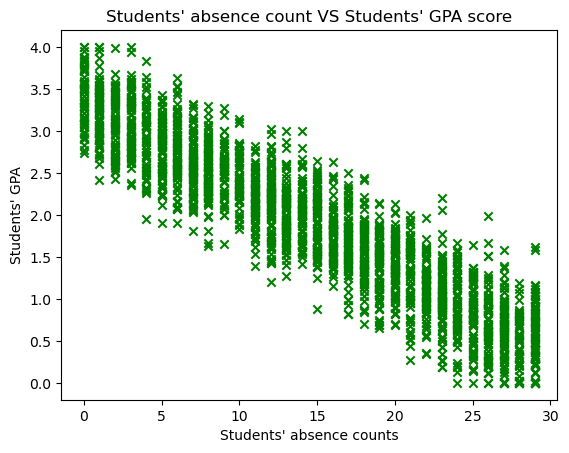

In [56]:
plt.scatter(student_list_data['Absences'], student_list_data['GPA'], marker = 'x', color = 'g')
plt.title("Students' absence count VS Students' GPA score")
plt.xlabel("Students' absence counts")
plt.ylabel("Students' GPA")
plt.show()

As shown by the correlation value and the scatter plot, there is a strong negative correlation between the students' absences counts and their GPA score.
That is to say, the more they absence, the lower the GPA score they achieved

#### A2.6

The strong negative correlation in absence count alone can not be the cause of low GPA scores as GPA score is mostly decided by the academic performances in periodic tests and the absence count only reflects how much time the students attended classes to learn. However, they can also learn at home and would still be able to perform well in tests.
In reality, by looking at the graph above, we can only see a general downwards trend. However, the GPA range of students at a certain absence count is large, meaning that it can vary a lot. Therefore, it is not really accurate to depend on the correlation between absence count and GPA to predict a GPA of students based on absence counts. In other words, it is not a direct cause of low grade class solely by absences.

In [57]:
# A2.7

fun = {"mean", "median", "std", lambda x: np.percentile(x, 75) - np.percentile(x, 25)}

student_list_reduced = student_list_data.drop(columns = ['StudentID', 'Age', 'StudyTimeWeekly', 'ParentalSupport'])

student_absences = student_list_data.groupby('GradeClass')['Absences'].agg(fun)
student_gpa = student_list_data.groupby('GradeClass')['GPA'].agg(fun)

# print(student_absences)
# print(student_gpa)

students_groupby_gc = pd.merge(student_absences, student_gpa, on = 'GradeClass')
students_groupby_gc

,mean_x,std_x,median_x,<lambda_0>_x,mean_y,std_y,median_y,<lambda_0>_y
GradeClass,,,,,,,,
A,1.475410,1.659383,1.0,3.0,3.681490,0.163589,3.618273,0.275281
B,3.308824,2.500782,3.0,4.0,3.227285,0.143109,3.219432,0.242832
C,6.433628,3.562318,6.0,5.0,2.732964,0.145818,2.723828,0.250655
D,11.140921,3.783787,11.0,6.0,2.249837,0.137388,2.240924,0.230745
F,21.008000,5.033246,21.0,8.0,1.181513,0.513394,1.234141,0.788061


In [58]:
# A2.8

students_groupby_gc.rename(
    columns={"":"GradeClass",
             "std_x":"Absences_std", 
             "<lambda_0>_x":"Absences_IQR",
             "mean_x":"Absences_mean",
             "median_x":"Absences_median",
             "std_y":"GPA_std",
             "<lambda_0>_y":"GPA_IQR",
             "mean_y":"GPA_mean",
             "median_y":"GPA_median"},
    inplace = True
)
students_groupby_gc = students_groupby_gc.reset_index()
students_groupby_gc

,GradeClass,Absences_mean,Absences_std,Absences_median,Absences_IQR,GPA_mean,GPA_std,GPA_median,GPA_IQR
0,A,1.475410,1.659383,1.0,3.0,3.681490,0.163589,3.618273,0.275281
1,B,3.308824,2.500782,3.0,4.0,3.227285,0.143109,3.219432,0.242832
2,C,6.433628,3.562318,6.0,5.0,2.732964,0.145818,2.723828,0.250655
3,D,11.140921,3.783787,11.0,6.0,2.249837,0.137388,2.240924,0.230745
4,F,21.008000,5.033246,21.0,8.0,1.181513,0.513394,1.234141,0.788061


### A3. Supervised Learning

#### A3.1

Supervised machine learning that the model is trained on labeled training data. The training data should contains input features and the correct output (which is labeled). In this case, for the student_list_data dataset, 'GradeClass' is being used as the label to indicate the correct answer that the model is expected to output

Training and testing are the two stages of conducting machine learning. Training happens on the training dataset and testing is conducted on testing dataset. The two datasets must not overlap. In the case of supervised ML, the model is fed in the features and labels in the training dataset. Then, without knowing the labels in the testing dataset, it performs predictions about the answers based on the features in the testing dataset. After that, the model is judged by comparing the answers that the model outputs with the labels in the original testing dataset to improve the model.

Without holding a dataset for testing the model, we can not observe its behaviour to evaluate its' accuracy. Hence, if the model is not accurate enough, we would not be able to know that and improve the model.

#### A3.2

Consider the columns in the dataset:

StudentID: Exclude. This columns stores the student's ID to indicate the identity of a student and does not contribute to predict a grade.

Age: Keep. Students' age can impact to their study habits and overall academic behaviours. Therefore, it is quite meaningful to predict the grades.

StudyTimeWeekly: Keep. This feature measures the academic behaviour of students and is highly correlated to their performances in tests.

Absences: Keep. Absence counts also measure academic behaviours of students.

ParentalSupport: Keep. The involvement of parent in the study path of students' contribute socially and mentally to the overall performance of students academically.

GPA: Exclude. GPA and GradeClass almost reflects the same information. By keeping GPA as a feature, we might mislead the model into giving the grade based on the GPA score and not predicting the grade based on other features.

Therefore, the features that are fed in the model would contain ('Age', 'StudyTimeWeekly', 'Absences', 'ParentalSupport')

In [59]:
# A3.3

X = student_list_data.drop(columns=['StudentID', 'GPA', 'GradeClass'], axis = 1).values # Get the data features by extracting values from the dataset excluding the non useful columns as well as the label
Y = student_list_data['GradeClass'].values # Get the labels for supervised ML by extraing values in the label column

from sklearn.model_selection import train_test_split

# Use train_test_split to split the dataset for training and testing, keeping 70% for training
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.3, random_state = 0
)

If I only have a very small dataset, I would not use the 70/30 split for training and testing sets.
This is because in that case, the amount of data fed in the model would be really small and hence, the model would not be learning really well.
This will result in the model not being accurate enough.
In this case, I would increase the train test set size to 80% or so to help ensure that the model is trained enough

### A4. Classification (training)

#### A4.1a

Scaling the data features is needed because the features in the dataset are measure in different ranges, which makes some features larger than others. Therefore, when learning, they will dominate the process, making the model biased.

In this dataset, Age is measured between 15 and 19 while Absences is measured up to 30. Therefore, when put in the model without scaling, the values in Absences is larger than those of Age and distance-based models would consider more important and have more impact on the process of predicting.

In [60]:
# A4.1b

# Import StandardScaler for scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Scale the values in train and test set
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(X_train)
print(X_test)

[[ 1.36813334  0.06293379  0.62085667  1.68331283]
 [-0.43475691 -1.27902856 -0.67779534 -1.00754369]
 [ 0.46668821  1.61506169  1.56533087 -1.90449586]
 ...
 [ 0.46668821  0.54927839 -0.55973607 -1.00754369]
 [-1.33620204 -0.93615514  0.73891595 -0.11059151]
 [-0.43475691  0.83028654  1.32921232 -1.90449586]]
[[ 1.36813334  1.44374878  0.73891595 -1.90449586]
 [ 1.36813334 -0.66292212 -1.74032881  0.78636066]
 [ 0.46668821 -1.40864289  1.09309377 -0.11059151]
 ...
 [ 0.46668821  1.21233185 -1.50421026 -0.11059151]
 [-0.43475691  1.14988202  1.21115304 -0.11059151]
 [ 1.36813334 -1.05153646 -0.91391389 -0.11059151]]


By applying the scaler on X_train and X_test, the values store in those sets (which are in 'Age', 'StudyTimeWeekly', 'Absences', 'ParentalSupport') are scaled.

#### A4.2

a. Support vector machine (SVM) is a supervised machine learning algorithm that finds an optimal separating hyperplane to classify data by maximizing the margin between classes.

b. Kernel in SVM is the function to adjust the pattern and the shape of margin to separates the classes.

In [61]:
#A4.2c

from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Train a Support Vector Machine Classifier using linear kernel

clf_lin = svm.SVC(kernel='linear', random_state=42)
clf_lin.fit(X_train, Y_train)

SVC(kernel='linear', random_state=42)

In [62]:
# Train a Support Vector Machine Classifier using RBF kernel

clf_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf_rbf.fit(X_train, Y_train)

SVC(random_state=42)

#### A4.3

Train other classifier to decided which one is the most accurate for this dataset

In [63]:
# Train a decision tree classifier on the current dataset

from sklearn import tree

dtc = tree.DecisionTreeClassifier()
dtc.fit(X_train, Y_train)

DecisionTreeClassifier()

In [64]:
# Train a Random Forest classifier on the current dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

rfc = RandomForestClassifier(n_estimators = 20,
                             criterion = 'entropy',
                             random_state = 0)

rfc.fit(X_train, Y_train)

RandomForestClassifier(criterion='entropy', n_estimators=20, random_state=0)

In [65]:
# Train a Logistic Regression Classifier on the current dataset

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lrc = LogisticRegression(max_iter=1000, random_state=0)

lrc.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [66]:
# Train a KNN Classifier on the current dataset

from sklearn.neighbors import KNeighborsClassifier

knnc = KNeighborsClassifier(n_neighbors=5)
knnc.fit(X_train, Y_train)

KNeighborsClassifier()

### A5 Classification (prediction)

In [67]:
# Predict the label for the testing set using SVC with linear kernel

Y_pred_lin_on_train = clf_lin.predict(X_train)
Y_pred_lin = clf_lin.predict(X_test)

print("SVC Linear kernel results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_lin_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_lin))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_lin))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_lin))

SVC Linear kernel results:
Accuracy on train set: 0.7595367847411444
Accuracy on test set: 0.7634920634920634

Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00        21
           B       0.53      0.54      0.53        69
           C       0.56      0.68      0.61        96
           D       0.68      0.55      0.61       116
           F       0.90      0.96      0.93       328

    accuracy                           0.76       630
   macro avg       0.53      0.55      0.54       630
weighted avg       0.74      0.76      0.75       630


Confusion Matrix:
 [[  0  21   0   0   0]
 [  0  37  31   1   0]
 [  0  12  65  16   3]
 [  0   0  21  64  31]
 [  0   0   0  13 315]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
# Predict the label for the testing set using SVC with RBF kernel

Y_pred_rbf_on_train = clf_rbf.predict(X_train)
Y_pred_rbf = clf_rbf.predict(X_test)

print("SVC RBF kernel results")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_rbf_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_rbf))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_rbf))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rbf))

SVC RBF kernel results
Accuracy on train set: 0.7772479564032697
Accuracy on test set: 0.7428571428571429

Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00        21
           B       0.54      0.46      0.50        69
           C       0.51      0.64      0.57        96
           D       0.60      0.53      0.57       116
           F       0.90      0.95      0.92       328

    accuracy                           0.74       630
   macro avg       0.51      0.52      0.51       630
weighted avg       0.72      0.74      0.73       630


Confusion Matrix:
 [[  0  19   2   0   0]
 [  0  32  35   2   0]
 [  0   8  61  24   3]
 [  0   0  21  62  33]
 [  0   0   0  15 313]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
# Predict the label for the testing set using Decision Tree Classifier

Y_pred_dtc_on_train = dtc.predict(X_train)
Y_pred_dtc = dtc.predict(X_test)

print("Decision Tree Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_dtc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_dtc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_dtc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_dtc))

Decision Tree Classifier results:
Accuracy on train set: 1.0
Accuracy on test set: 0.6825396825396826

Classification Report:
               precision    recall  f1-score   support

           A       0.45      0.48      0.47        21
           B       0.42      0.39      0.41        69
           C       0.41      0.43      0.42        96
           D       0.50      0.47      0.48       116
           F       0.89      0.91      0.90       328

    accuracy                           0.68       630
   macro avg       0.54      0.53      0.53       630
weighted avg       0.68      0.68      0.68       630


Confusion Matrix:
 [[ 10  10   1   0   0]
 [  9  27  27   6   0]
 [  3  23  41  23   6]
 [  0   4  26  55  31]
 [  0   0   4  27 297]]


In [70]:
# Predict the label for the testing set using Random Forest Classifier

Y_pred_rfc_on_train = rfc.predict(X_train)
Y_pred_rfc = rfc.predict(X_test)

print("Random Forest Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_rfc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_rfc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_rfc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rfc))

Random Forest Classifier results:
Accuracy on train set: 0.9986376021798365
Accuracy on test set: 0.7380952380952381

Classification Report:
               precision    recall  f1-score   support

           A       0.53      0.43      0.47        21
           B       0.49      0.41      0.44        69
           C       0.50      0.61      0.55        96
           D       0.62      0.49      0.55       116
           F       0.90      0.95      0.93       328

    accuracy                           0.74       630
   macro avg       0.61      0.58      0.59       630
weighted avg       0.73      0.74      0.73       630


Confusion Matrix:
 [[  9  11   1   0   0]
 [  7  28  30   4   0]
 [  1  16  59  17   3]
 [  0   2  26  57  31]
 [  0   0   2  14 312]]


In [71]:
# Predict the label for the testing set using Logistic Regression Classifier

Y_pred_lrc_on_train = lrc.predict(X_train)
Y_pred_lrc = lrc.predict(X_test)

print("Logistic Regression Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_lrc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_lrc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_lrc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_lrc))

Logistic Regression Classifier results:
Accuracy on train set: 0.7636239782016349
Accuracy on test set: 0.7666666666666667

Classification Report:
               precision    recall  f1-score   support

           A       1.00      0.05      0.09        21
           B       0.55      0.52      0.54        69
           C       0.56      0.70      0.62        96
           D       0.69      0.53      0.60       116
           F       0.90      0.97      0.93       328

    accuracy                           0.77       630
   macro avg       0.74      0.55      0.55       630
weighted avg       0.77      0.77      0.75       630


Confusion Matrix:
 [[  1  20   0   0   0]
 [  0  36  32   1   0]
 [  0   9  67  17   3]
 [  0   0  21  61  34]
 [  0   0   0  10 318]]


In [72]:
# Predict the label for the testing set using KNN Classifier

Y_pred_knnc_on_train = knnc.predict(X_train)
Y_pred_knnc = knnc.predict(X_test)

print("KNN Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_knnc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_knnc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_knnc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_knnc))

KNN Classifier results:
Accuracy on train set: 0.7970027247956403
Accuracy on test set: 0.6936507936507936

Classification Report:
               precision    recall  f1-score   support

           A       0.29      0.10      0.14        21
           B       0.43      0.43      0.43        69
           C       0.42      0.51      0.46        96
           D       0.52      0.41      0.46       116
           F       0.89      0.94      0.92       328

    accuracy                           0.69       630
   macro avg       0.51      0.48      0.48       630
weighted avg       0.68      0.69      0.68       630


Confusion Matrix:
 [[  2  15   4   0   0]
 [  4  30  32   3   0]
 [  1  21  49  23   2]
 [  0   4  29  48  35]
 [  0   0   2  18 308]]


#### A5.3

Based on the accuracy of the classifiers, the SVC using linear kernel works better than the SVC using RBF kernel on this dataset.
Both kernels on the SVC classifiers had higher accuracy than KNN and Decision Tree classifiers.
Logistic Regression had the highest accuracy when predicting the labels for the testing set.

#### A5.4

Decision Tree and Random Forest had a really high accuracy on the train set but a rather normal accuracy on the test set, signalling overfitting or high variance.
KNN is slightly overfitting while the three remaining classifiers including both SVCs and Logistic Regression Classifier seems to have most balacing between bias and variance.

Since Logistic Regression had the highest accuracy among the three best models, it is the best classifier for this dataset

#### Tune the parameters in the models

In [73]:
# Recall the data features for training
X = student_list_data.drop(columns=['StudentID', 'GPA', 'GradeClass'], axis = 1).values # Get the data features by extracting values from the dataset excluding the non useful columns as well as the label
Y = student_list_data['GradeClass'].values # Get the labels for supervised ML by extraing values in the label column

# Scale the X values
X = sc.fit_transform(X)

In [74]:
# Tune SVC using linear kernel using GridSearchCV for auto parameter tuning

# Parameter grid
param_grid_svc_lin = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_svc_lin = GridSearchCV(svm.SVC(kernel="linear", random_state=0), param_grid_svc_lin, cv=5, scoring='accuracy')

# Train the model on the whole dataset since GridSearchCV provides cross validation already
grid_svc_lin.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=SVC(kernel='linear', random_state=0),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced']},
             scoring='accuracy')

In [75]:
Y_pred = grid_svc_lin.predict(X)

print("SVC Linear kernel results:")
# print("Accuracy on train set:", accuracy_score(Y_pred, Y))
print("Accuracy on test set:", accuracy_score(Y_pred, Y))
print("\nClassification Report:\n", classification_report(Y_pred, Y))
print("\nConfusion Matrix:\n", confusion_matrix(Y_pred, Y))

SVC Linear kernel results:
Accuracy on test set: 0.765490943755958

Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.51      0.57      0.54       182
           C       0.68      0.57      0.62       405
           D       0.55      0.60      0.57       340
           F       0.95      0.91      0.93      1171

    accuracy                           0.77      2098
   macro avg       0.54      0.53      0.53      2098
weighted avg       0.79      0.77      0.78      2098


Confusion Matrix:
 [[   0    0    0    0    0]
 [  55  104   23    0    0]
 [   6   99  229   69    2]
 [   0    1   83  203   53]
 [   0    0    4   97 1070]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [76]:
# Tune SVC using RBF kernel using GridSearchCV for auto parameter tuning

param_grid_svc_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'class_weight': [None, 'balanced']
}

grid_svc_rbf = GridSearchCV(svm.SVC(kernel='rbf', random_state=0), param_grid_svc_rbf, cv=5, scoring='accuracy')

# Train the model on the whole dataset since GridSearchCV provides cross-validation already
grid_svc_rbf.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=0),
             param_grid={'C': [0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'gamma': [0.001, 0.01, 0.1, 1]},
             scoring='accuracy')

In [77]:
Y_pred = grid_svc_rbf.predict(X)
print(len(Y_pred))
print(len(Y))

print("SVC RBF kernel results:")
# print("Accuracy on train set:", accuracy_score(Y_pred, Y))
print("Accuracy on test set:", accuracy_score(Y_pred, Y))
print("\nClassification Report:\n", classification_report(Y_pred, Y))
print("\nConfusion Matrix:\n", confusion_matrix(Y_pred, Y))

2098
2098
SVC RBF kernel results:
Accuracy on test set: 0.7673975214489991

Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.58      0.56      0.57       211
           C       0.65      0.58      0.61       381
           D       0.55      0.60      0.57       339
           F       0.95      0.92      0.93      1167

    accuracy                           0.77      2098
   macro avg       0.55      0.53      0.54      2098
weighted avg       0.79      0.77      0.78      2098


Confusion Matrix:
 [[   0    0    0    0    0]
 [  56  119   36    0    0]
 [   5   83  220   71    2]
 [   0    2   79  203   55]
 [   0    0    4   95 1068]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [78]:
# Tune the Logistic Regression using GridSearchCV for auto parameter tuning

param_grid_lrc = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

new_lrc = LogisticRegression(max_iter=10000, random_state=0)

grid_lrc = GridSearchCV(new_lrc, param_grid_lrc, cv=5, scoring='accuracy')

# Train the model on the whole dataset since GridSearchCV provides cross-validation already
grid_lrc.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=10000, random_state=0),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [79]:
Y_pred = grid_svc_lin.predict(X)
print(len(Y_pred))
print(len(Y))

print("Logistic Regression results:")
# print("Accuracy on train set:", accuracy_score(Y_pred, Y))
print("Accuracy on test set:", accuracy_score(Y_pred, Y))
print("\nClassification Report:\n", classification_report(Y_pred, Y))
print("\nConfusion Matrix:\n", confusion_matrix(Y_pred, Y))

2098
2098
Logistic Regression results:
Accuracy on test set: 0.765490943755958

Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.51      0.57      0.54       182
           C       0.68      0.57      0.62       405
           D       0.55      0.60      0.57       340
           F       0.95      0.91      0.93      1171

    accuracy                           0.77      2098
   macro avg       0.54      0.53      0.53      2098
weighted avg       0.79      0.77      0.78      2098


Confusion Matrix:
 [[   0    0    0    0    0]
 [  55  104   23    0    0]
 [   6   99  229   69    2]
 [   0    1   83  203   53]
 [   0    0    4   97 1070]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [80]:
# Tune the KNN using GridSearchCV for auto parameter tuning

param_grid_knn = {
    'n_neighbors': list(range(7, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy'
)

# Train the model on the whole dataset since GridSearchCV provides cross-validation already

grid_knn.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [7, 8, 9, 10, 11, 12, 13, 14, 15, 16,
                                         17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
                                         27, 28, 29, 30],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [81]:
Y_pred = grid_knn.predict(X)

print("KNN results:")
# print("Accuracy on train set:", accuracy_score(Y_pred, Y))
print("Accuracy on test set:", accuracy_score(Y_pred, Y))
print("\nClassification Report:\n", classification_report(Y_pred, Y))
print("\nConfusion Matrix:\n", confusion_matrix(Y_pred, Y))

KNN results:
Accuracy on test set: 0.9161105815061964

Classification Report:
               precision    recall  f1-score   support

           A       0.62      1.00      0.77        38
           B       0.78      0.84      0.81       190
           C       0.88      0.83      0.86       361
           D       0.83      0.89      0.86       347
           F       0.99      0.96      0.98      1162

    accuracy                           0.92      2098
   macro avg       0.82      0.90      0.85      2098
weighted avg       0.92      0.92      0.92      2098


Confusion Matrix:
 [[  38    0    0    0    0]
 [  21  160    9    0    0]
 [   2   42  300   17    0]
 [   0    2   28  308    9]
 [   0    0    2   44 1116]]


In [82]:
# Tune the parameters in decision tree

# Parameter grid
param_grid_dtc = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV
grid_dtc = GridSearchCV(
    estimator=dtc,
    param_grid=param_grid_dtc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dtc.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [83]:
# Predict the label for the testing set using Decision Tree Classifier

Y_pred_dtc_on_train = dtc.predict(X_train)
Y_pred_dtc = dtc.predict(X_test)

print("Decision Tree Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_dtc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_dtc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_dtc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_dtc))

Decision Tree Classifier results:
Accuracy on train set: 1.0
Accuracy on test set: 0.6825396825396826

Classification Report:
               precision    recall  f1-score   support

           A       0.45      0.48      0.47        21
           B       0.42      0.39      0.41        69
           C       0.41      0.43      0.42        96
           D       0.50      0.47      0.48       116
           F       0.89      0.91      0.90       328

    accuracy                           0.68       630
   macro avg       0.54      0.53      0.53       630
weighted avg       0.68      0.68      0.68       630


Confusion Matrix:
 [[ 10  10   1   0   0]
 [  9  27  27   6   0]
 [  3  23  41  23   6]
 [  0   4  26  55  31]
 [  0   0   4  27 297]]


In [84]:
# Tune the parameters in Random Forest

param_grid_rfc = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# GridSearchCV
grid_rfc = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid_rfc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rfc.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(criterion='entropy',
                                              n_estimators=20, random_state=0),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='accuracy')

In [85]:
Y_pred_rfc_on_train = rfc.predict(X_train)
Y_pred_rfc = rfc.predict(X_test)

print("Random Forest Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_rfc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_rfc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_rfc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rfc))

Random Forest Classifier results:
Accuracy on train set: 0.9986376021798365
Accuracy on test set: 0.7380952380952381

Classification Report:
               precision    recall  f1-score   support

           A       0.53      0.43      0.47        21
           B       0.49      0.41      0.44        69
           C       0.50      0.61      0.55        96
           D       0.62      0.49      0.55       116
           F       0.90      0.95      0.93       328

    accuracy                           0.74       630
   macro avg       0.61      0.58      0.59       630
weighted avg       0.73      0.74      0.73       630


Confusion Matrix:
 [[  9  11   1   0   0]
 [  7  28  30   4   0]
 [  1  16  59  17   3]
 [  0   2  26  57  31]
 [  0   0   2  14 312]]


In [86]:
# Stack the tuned models together and use Gradient Boosting as the meta-learner to train the best model

from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier

# Base models to use: The hyperparameter-tuned models
base_learners = [
    ('svc_lin', grid_svc_lin.best_estimator_),
    ('svc_rbf', grid_svc_rbf.best_estimator_),
    ('log_reg', grid_lrc.best_estimator_),
    ('knn', grid_knn.best_estimator_),
    ('decision_tree', grid_dtc.best_estimator_),
    ('random_forest', grid_rfc.best_estimator_)
]

# Meta model (Gradient Boosting will learn how to combine base models)
meta_learner = GradientBoostingClassifier(random_state=42)

# Stacking classifier
stacked_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,          # internal cross-validation
    n_jobs=-1
)

stacked_model.fit(X_train, Y_train)

StackingClassifier(cv=5,
                   estimators=[('svc_lin',
                                SVC(C=0.1, kernel='linear', random_state=0)),
                               ('svc_rbf',
                                SVC(C=100, gamma=0.001, random_state=0)),
                               ('log_reg',
                                LogisticRegression(C=10, max_iter=10000,
                                                   random_state=0,
                                                   solver='saga')),
                               ('knn',
                                KNeighborsClassifier(metric='euclidean',
                                                     n_neighbors=30,
                                                     weights='distance')),
                               ('decision_tree',
                                DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=5,
                                                       min_samples_leaf=2,
                                                       min_samples_split=10)),
                               ('random_forest',
                                RandomForestClassifier(criterion='entropy',
                                                       max_depth=10,
                                                       min_samples_leaf=4,
                                                       min_samples_split=10,
                                                       n_estimators=200,
                                                       random_state=0))],
                   final_estimator=GradientBoostingClassifier(random_state=42),
                   n_jobs=-1)

In [87]:
Y_pred_rfc_on_train = rfc.predict(X_train)
Y_pred_rfc = rfc.predict(X_test)

print("Stacked-model GB Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_rfc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_rfc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_rfc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rfc))

Stacked-model GB Classifier results:
Accuracy on train set: 0.9986376021798365
Accuracy on test set: 0.7380952380952381

Classification Report:
               precision    recall  f1-score   support

           A       0.53      0.43      0.47        21
           B       0.49      0.41      0.44        69
           C       0.50      0.61      0.55        96
           D       0.62      0.49      0.55       116
           F       0.90      0.95      0.93       328

    accuracy                           0.74       630
   macro avg       0.61      0.58      0.59       630
weighted avg       0.73      0.74      0.73       630


Confusion Matrix:
 [[  9  11   1   0   0]
 [  7  28  30   4   0]
 [  1  16  59  17   3]
 [  0   2  26  57  31]
 [  0   0   2  14 312]]


In [88]:
# Define param grid for the meta-learner
param_grid_meta = {
    'final_estimator__n_estimators': [100, 200, 300],
    'final_estimator__learning_rate': [0.01, 0.1, 0.2],
    'final_estimator__max_depth': [3, 4, 5],
    'final_estimator__subsample': [0.8, 1.0]
}

# Wrap stacking model inside GridSearchCV
grid_meta = GridSearchCV(
    estimator=stacked_model,
    param_grid=param_grid_meta,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on training data
grid_meta.fit(X, Y)

print("Best meta-learner params:", grid_meta.best_params_)
print("Best CV accuracy:", grid_meta.best_score_)

best_stacked_model = grid_meta.best_estimator_

Best meta-learner params: {'final_estimator__learning_rate': 0.01, 'final_estimator__max_depth': 3, 'final_estimator__n_estimators': 100, 'final_estimator__subsample': 0.8}
Best CV accuracy: 0.7526264348221389


In [89]:
Y_pred_rfc_on_train = grid_meta.predict(X_train)
Y_pred_rfc = grid_meta.predict(X_test)

print("Meta tuned GB Classifier results:")
print("Accuracy on train set:", accuracy_score(Y_train, Y_pred_rfc_on_train))
print("Accuracy on test set:", accuracy_score(Y_test, Y_pred_rfc))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_rfc))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rfc))

Meta tuned GB Classifier results:
Accuracy on train set: 0.7629427792915532
Accuracy on test set: 0.7761904761904762

Classification Report:
               precision    recall  f1-score   support

           A       0.89      0.38      0.53        21
           B       0.56      0.57      0.56        69
           C       0.55      0.52      0.53        96
           D       0.69      0.59      0.64       116
           F       0.90      0.99      0.94       328

    accuracy                           0.78       630
   macro avg       0.72      0.61      0.64       630
weighted avg       0.77      0.78      0.77       630


Confusion Matrix:
 [[  8  13   0   0   0]
 [  1  39  28   1   0]
 [  0  18  50  25   3]
 [  0   0  13  68  35]
 [  0   0   0   4 324]]


### A6. Independent evaluation

In [90]:
# Read in the Student_List_A2_Submission.csv
df = pd.read_csv("Student_List_A2_Submission.csv")

print(df.shape)
df.head()

(161, 5)


,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport
0,5000,16,13.274090,27,1
1,5001,17,16.926360,6,2
2,5002,15,4.225258,15,3
3,5003,16,18.839829,17,3
4,5004,15,9.075075,6,2


In [91]:
# Generating the data features to feed to the model to predict
X = df.drop(columns=['StudentID'], axis=1).values
# print(X)

In [92]:
# Scale the data
X = sc.fit_transform(X)
# print(X)

In [93]:
# Predict the GradeClass for students in list

df['GradeClass'] = grid_meta.predict(X)
print(df.shape)
df.head()

(161, 6)


,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GradeClass
0,5000,16,13.274090,27,1,F
1,5001,17,16.926360,6,2,C
2,5002,15,4.225258,15,3,F
3,5003,16,18.839829,17,3,F
4,5004,15,9.075075,6,2,C


In [94]:
# Dropping unnecessary columns

df = df.drop(columns=["Age", "StudyTimeWeekly", "Absences", "ParentalSupport"], axis = 1)
print(df.shape)

(161, 2)


In [95]:
# Change the value of GradeClass to numeric values instead of A-F

def apply_numeric_grades (x):
    if (x == "A"):
        return 0
    if (x == "B"):
        return 1
    if (x == "C"):
        return 2
    if (x == "D"):
        return 3
    return 4

df['GradeClass'] = df['GradeClass'].apply(apply_numeric_grades)
df.head()

,StudentID,GradeClass
0,5000,4
1,5001,2
2,5002,4
3,5003,4
4,5004,2


In [96]:
# Save the dataset as a csv file

df.to_csv('35767863-MinhGiaPhucVan-v1.csv', index = False)

In [3]:
# Task B. Selection of Dataset with missing data and Clustering

In [4]:
# Re-import the packages to not rerun the whole notebook when opening

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
%matplotlib inline

In [5]:
# B1

# Load the dataset

df = pd.read_csv("Life_Expectancy_Data.csv")

print(df.shape)

df.head()

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [6]:
# B2

# Renaming the columns
df.rename(
    columns={
        "Life expectancy ":"Life_expectancy",
    },
    inplace=True
)

df.head()

,Country,Year,Status,Life_expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [7]:
# Count missing entries of "Life_expectancy" column
print(df['Life_expectancy'].isna().sum())

# Count missing entries of "Alcohol" column
print(df['GDP'].isna().sum())

10
448


In [8]:
# Since I perform clustering on "Life_expectancy" and "Alcohol" only, I want to narrow down the dataset and ignore the entries within other columns
# This also ignores missing entries in other columns as they are irrelevant to clustering

df = df[['Life_expectancy', 'GDP']]

df.shape

(2938, 2)

In [9]:
# Since there are missing entries as shown above, I want to fix by removing them

df = df.dropna()

print(df.shape)

df.head()

(2485, 2)


,Life_expectancy,GDP
0,65.0,584.259210
1,59.9,612.696514
2,59.9,631.744976
3,59.5,669.959000
4,59.2,63.537231


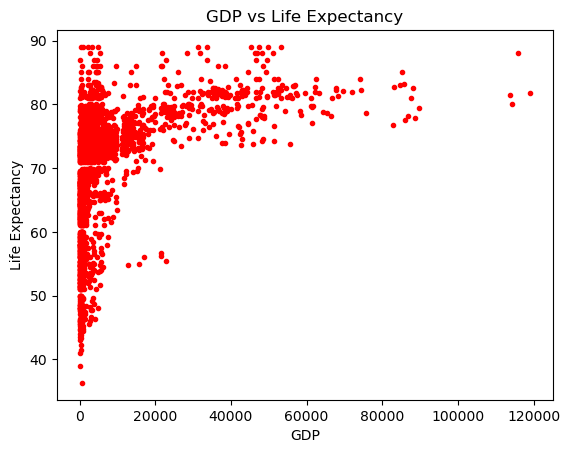

In [10]:
# B3

from sklearn.cluster import KMeans

# Use scatter plot to visualize the data before clustering

Life_expectancy = df['Life_expectancy']
GDP = df['GDP']

plt.scatter(GDP, Life_expectancy, marker='.', color='r')
plt.ylabel("Life Expectancy")
plt.xlabel("GDP")
plt.title("GDP vs Life Expectancy")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=2, n_init=10).fit(df[['GDP', 'Life_expectancy']])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


For my choice of k = 2, after observing the visualization of the data, I noticed that countries that have a high GDP of over 20000 USD most likely to have a life expectancy of over 70. Therefore, I want to emphasize and depict this feature. Although there are many data that shows that there are still many countries with >70 years old life expectancy that have low GDP but that is not my aim for this task.

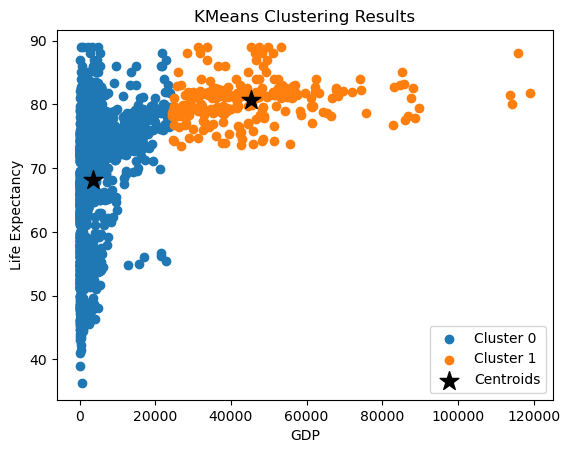

In [13]:
# Visualizing the data after clustering
for i in range(kmeans.n_clusters):
    plt.scatter(
        GDP[kmeans.labels_ == i],
        Life_expectancy[kmeans.labels_ == i],
        label=f"Cluster {i}"
    )

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='black', marker='*', s=200, label="Centroids"
)

# Labels and legend
plt.ylabel("Life Expectancy")
plt.xlabel("GDP")
plt.title("KMeans Clustering Results")
plt.legend()
plt.show()

B5.
The reason I choose this dataset is because this is a real dataset that the data is tracked by The Global Health Observatory (GHO) and is really reliable for health data analysis. Therefore, a data science project based on this dataset brings benefits to real-world analysis needs.

The reason that KMeans clustering is an appropriate algorithm on this dataset is the fact that the dataset is huge and is updated year by year by new data. Therefore, it is not really convenient to look at the raw data. KMeans propose a way to group the data into groups that may emphasizes the trends when looked at.

B6.
As stated above, I noticed that there is a one-way relation between high GDP and high life expectancy. Therefore, when conduct clustering, I expect the model to reflect that feature. The outcome of the model exactly matches my expectations.